# 🔍 Actividad 04: Calidad de los Datos
---
**Entrada:** CSVs de `data/02_interim/`  
**Salida:** `data/04_reports/reporte_calidad_datos.txt`

> Análisis visual de nulos, duplicados y outliers para las 3 fuentes del pipeline.


In [1]:

import os, sys, json, glob, re, warnings, unicodedata
import numpy as np
import pandas as pd
import matplotlib

import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid', palette='muted')

# Navegar a la raíz del proyecto
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir(os.path.abspath('..'))
print(f"Directorio: {os.getcwd()}")

with open('data/02_interim/pipeline_config.json', 'r', encoding='utf-8') as f:
    CFG = json.load(f)
DIRS = CFG['DIRS']
INTERIM = DIRS['interim']
REPORTS = DIRS['reports']
PROCESSED = DIRS['processed']
print("Configuración cargada OK")


Directorio: D:\CICLO 9\Machine-Learning-Multimodal--Agro-NLP-Clima-
Configuración cargada OK


## 4.1 Función de Diagnóstico de Calidad

In [2]:

def quality_report(df, name, key_cols=None):
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(f"  Shape: {df.shape[0]:,} filas x {df.shape[1]} columnas")
    
    # Nulos
    nulls = df.isnull().sum()
    nulls_pct = (nulls/len(df)*100).round(2)
    null_df = pd.DataFrame({'Nulos': nulls, '% Nulos': nulls_pct})
    null_df = null_df[null_df['Nulos'] > 0].sort_values('Nulos', ascending=False)
    
    if len(null_df) > 0:
        print(f"\n  Columnas con valores nulos ({len(null_df)}):")
        print(null_df.to_string())
    else:
        print("  ✅ Sin valores nulos.")
    
    # Duplicados
    if key_cols:
        dupes = df.duplicated(subset=key_cols).sum()
        print(f"\n  Duplicados (llave {key_cols}): {dupes}")
    else:
        dupes = df.duplicated().sum()
        print(f"\n  Duplicados totales: {dupes}")
    
    return null_df, dupes

df_m = pd.read_csv(f"{INTERIM}/midagri_limon_raw.csv")

df_ev_path = f"{INTERIM}/indeci_eventos_dbf.csv"
if not os.path.exists(df_ev_path):
    df_ev_path = f"{INTERIM}/indeci_resumen_prov.csv"
df_ev = pd.read_csv(df_ev_path, low_memory=False)

df_n  = pd.read_csv(f"{INTERIM}/agraria_noticias_raw.csv")

# Carga de NASA para calidad
df_nasa = pd.DataFrame()
nasa_path = f"data/03_processed_nasa/nasa_climatic_raw_values.csv"
if os.path.exists(nasa_path):
    df_nasa = pd.read_csv(nasa_path)

null_m,  dup_m  = quality_report(df_m,  "MIDAGRI — midagri_limon_raw.csv",    ['anho','mes','COD_UBIGEO','dsc_Cultivo'])
null_ev, dup_ev = quality_report(df_ev, "INDECI (Fallback Data)", ['ide_sinpad'] if 'ide_sinpad' in df_ev.columns else None)
null_n,  dup_n  = quality_report(df_n,  "AGRARIA.PE — agraria_noticias_raw.csv", ['url'])

if not df_nasa.empty:
    null_ns, dup_ns = quality_report(df_nasa, "NASA — nasa_climatic_raw_values.csv", ['fecha_evento','DEPARTAMENTO','PROVINCIA'])



  MIDAGRI — midagri_limon_raw.csv
  Shape: 19,573 filas x 10 columnas
  ✅ Sin valores nulos.

  Duplicados (llave ['anho', 'mes', 'COD_UBIGEO', 'dsc_Cultivo']): 0

  INDECI (Fallback Data)
  Shape: 224 filas x 17 columnas

  Columnas con valores nulos (16):
                         Nulos  % Nulos
emergencias                  2     0.89
pers_afectadas               2     0.89
pers_damnificadas            2     0.89
pers_desaparecidas           2     0.89
pers_lesionadas              2     0.89
pers_fallecidas              2     0.89
viv_afectadas                2     0.89
viv_destruidas               2     0.89
salud_afectadas              2     0.89
salud_destruidas             2     0.89
cultivo_has_afectadas        2     0.89
cultivo_has_perdidas         2     0.89
puentes_afectados            2     0.89
puentes_perdidos             2     0.89
carreteras_km_afectadas      2     0.89
carreteras_km_perdidas       2     0.89

  Duplicados totales: 1

  AGRARIA.PE — agraria_noticias_raw

## 4.2 Visualización de Nulos por Fuente

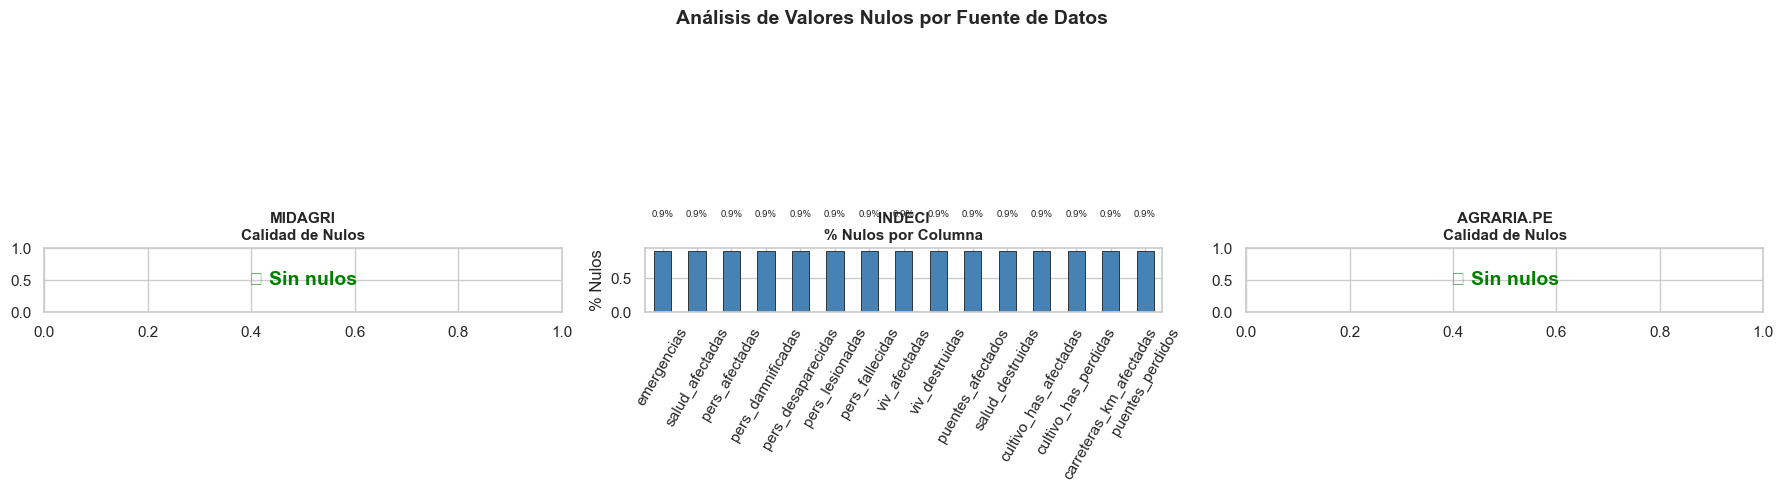

[OK] data\04_reports/g4_calidad_nulos.png


In [3]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

fuentes = [
    (df_m,  "MIDAGRI",    'mediumseagreen'),
    (df_ev, "INDECI",     'steelblue'),
    (df_n,  "AGRARIA.PE", 'coral'),
]

for ax, (df, nombre, color) in zip(axes, fuentes):
    nulls = (df.isnull().sum()/len(df)*100).sort_values(ascending=False)
    nulls = nulls[nulls > 0].head(15)
    if len(nulls) > 0:
        nulls.plot(kind='bar', ax=ax, color=color, edgecolor='black', linewidth=0.5)
        ax.set_title(f'{nombre}\n% Nulos por Columna', fontsize=11, fontweight='bold')
        ax.set_ylabel('% Nulos')
        ax.tick_params(axis='x', rotation=60)
        for p in ax.patches:
            if p.get_height() > 0:
                ax.text(p.get_x()+p.get_width()/2, p.get_height()+0.5,
                        f'{p.get_height():.1f}%', ha='center', fontsize=7)
    else:
        ax.text(0.5, 0.5, '✅ Sin nulos', ha='center', va='center',
                transform=ax.transAxes, fontsize=14, color='green', fontweight='bold')
        ax.set_title(f'{nombre}\nCalidad de Nulos', fontsize=11, fontweight='bold')

plt.suptitle('Análisis de Valores Nulos por Fuente de Datos', fontsize=14, fontweight='bold')
plt.tight_layout()
g_path = f"{REPORTS}/g4_calidad_nulos.png"
plt.savefig(g_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"[OK] {g_path}")


## 4.3 Análisis de Outliers — Producción MIDAGRI

Estadísticas de Producción (t):
  Min:          0.02
  Q1:           2.00
  Median:       5.86
  Q3:          16.00
  Max:      16010.00
  IQR:         14.00
  Outliers (1.5×IQR): 2,851 (14.6%)


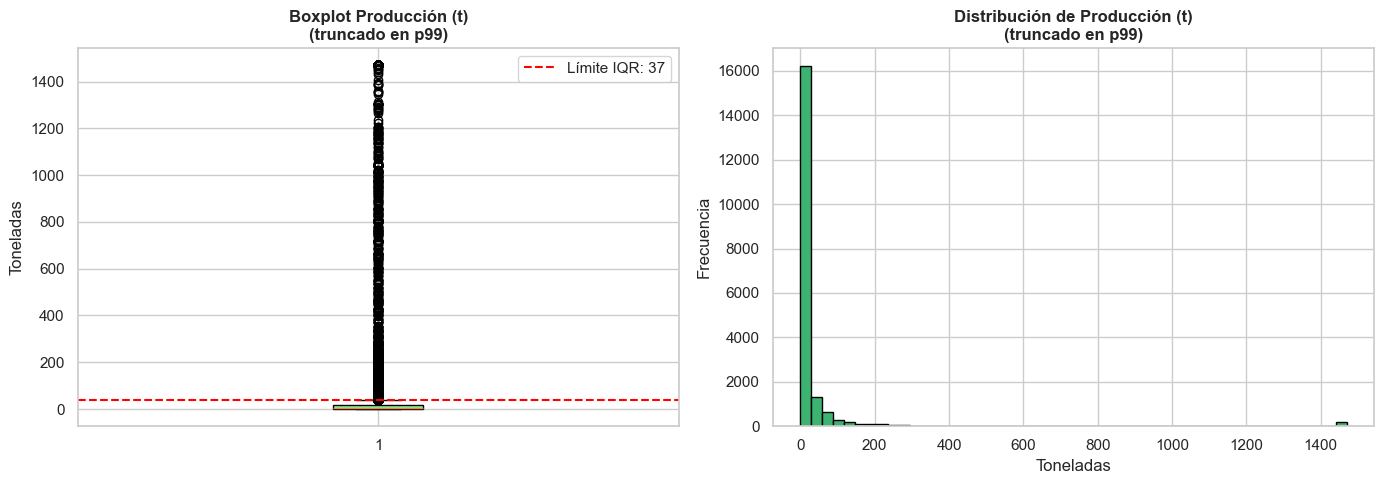

[OK] data\04_reports/g5_outliers_produccion.png


In [4]:

prod = pd.to_numeric(df_m['PRODUCCION(t)'], errors='coerce').dropna()
q1, q3 = prod.quantile(0.25), prod.quantile(0.75)
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
outliers = prod[(prod < lower) | (prod > upper)]

print(f"Estadísticas de Producción (t):")
print(f"  Min:    {prod.min():>10.2f}")
print(f"  Q1:     {q1:>10.2f}")
print(f"  Median: {prod.median():>10.2f}")
print(f"  Q3:     {q3:>10.2f}")
print(f"  Max:    {prod.max():>10.2f}")
print(f"  IQR:    {iqr:>10.2f}")
print(f"  Outliers (1.5×IQR): {len(outliers):,} ({len(outliers)/len(prod)*100:.1f}%)")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(prod.clip(upper=prod.quantile(0.99)), patch_artist=True,
                boxprops=dict(facecolor='lightgreen'))
axes[0].set_title('Boxplot Producción (t)\n(truncado en p99)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Toneladas')
axes[0].axhline(upper, color='red', linestyle='--', label=f'Límite IQR: {upper:.0f}')
axes[0].legend()

prod.clip(upper=prod.quantile(0.99)).hist(bins=50, ax=axes[1], color='mediumseagreen', edgecolor='black')
axes[1].set_title('Distribución de Producción (t)\n(truncado en p99)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Toneladas'); axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
g_path2 = f"{REPORTS}/g5_outliers_produccion.png"
plt.savefig(g_path2, dpi=150, bbox_inches='tight')
plt.show()
print(f"[OK] {g_path2}")


## 4.4 Resumen de Calidad — Tabla de Decisiones

In [5]:

# Tabla resumen de decisiones por fuente
resumen = {
    'Fuente': ['MIDAGRI', 'INDECI Eventos', 'AGRARIA.PE', 'NASA Climatic'],
    'Filas': [len(df_m), len(df_ev), len(df_n), len(df_nasa) if not df_nasa.empty else 0],
    'Columnas': [df_m.shape[1], df_ev.shape[1], df_n.shape[1], df_nasa.shape[1] if not df_nasa.empty else 0],
    'Cols con Nulos': [len(null_m), len(null_ev), len(null_n), len(df_nasa.isnull().sum()[df_nasa.isnull().sum()>0]) if not df_nasa.empty else 0],
    'Duplicados': [dup_m, dup_ev, dup_n, dup_ns if not df_nasa.empty else 0],
    'Acción': [
        'Renombrar cols + normalizar geo',
        'Filtrar fenómenos hidrometeorológicos + normalizar geo',
        'Limpiar HTML/URLs + normalizar texto',
        'Integrar por fecha y provincia'
    ]
}
df_resumen = pd.DataFrame(resumen)
print(df_resumen.to_string(index=False))

# Guardar reporte TXT
report_path = f"{REPORTS}/reporte_calidad_datos.txt"
with open(report_path, 'w', encoding='utf-8') as f:
    f.write("REPORTE DE CALIDAD DE DATOS — FASE 1\n")
    f.write("="*60+"\n")
    f.write(df_resumen.to_string(index=False))
    f.write("\n\nDecisiones de limpieza documentadas.\n")
print(f"\n[OK] {report_path}")
print("[ACTIVIDAD 04] COMPLETADA.")


        Fuente  Filas  Columnas  Cols con Nulos  Duplicados                                                 Acción
       MIDAGRI  19573        10               0           0                        Renombrar cols + normalizar geo
INDECI Eventos    224        17              16           1 Filtrar fenómenos hidrometeorológicos + normalizar geo
    AGRARIA.PE    528         5               0           0                   Limpiar HTML/URLs + normalizar texto
 NASA Climatic   5712        13               0           0                         Integrar por fecha y provincia

[OK] data\04_reports/reporte_calidad_datos.txt
[ACTIVIDAD 04] COMPLETADA.


## 4.5 NASA POWER — Calidad Climática
Validamos que los datos climáticos estén dentro de los rangos físicos esperados.

In [6]:

nasa_path = f"data/03_processed_nasa/nasa_climatic_raw_values.csv"
if os.path.exists(nasa_path):
    df_nasa = pd.read_csv(nasa_path)
    print("NASA - Nulos por columna:")
    print(df_nasa.isnull().sum())
    
    # Validaciones de rango
    t_out = ((df_nasa['T2M_MAX'] < 0) | (df_nasa['T2M_MAX'] > 50)).sum()
    p_out = (df_nasa['PRECTOTCORR'] < 0).sum()
    print(f"\nAlertas de Calidad NASA:")
    print(f"  - Temperaturas fuera de rango (0-50°C): {t_out}")
    print(f"  - Precipitaciones negativas: {p_out}")
    
    if t_out + p_out == 0:
        print("\n✅ Datos climáticos de NASA superan validación de rangos físicos.")
else:
    print("⚠️ No hay datos NASA para validar calidad.")


NASA - Nulos por columna:
DEPARTAMENTO         0
PROVINCIA            0
ANIO                 0
MES                  0
fecha_evento         0
ALLSKY_SFC_SW_DWN    0
PRECTOTCORR          0
QV2M                 0
RH2M                 0
T2M                  0
T2M_MAX              0
T2M_MIN              0
WS2M                 0
dtype: int64

Alertas de Calidad NASA:
  - Temperaturas fuera de rango (0-50°C): 0
  - Precipitaciones negativas: 0

✅ Datos climáticos de NASA superan validación de rangos físicos.
